# Validation of heuristic used for consensus path reconstruction and event detection

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

from sklearn.metrics import adjusted_mutual_info_score
import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys, count_trna_per_junction, get_core_alignment_lengths, summarize_clustering_thresholds, compute_within_between_cluster_distances, add_silhouette_scores
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_marginal_scatter, plot_cluster_count_distribution, plot_cluster_count_vs_diversity
from junction_analysis.plotting import plot_all_junctions_pairwise_distances, plot_junction_heatmap, plot_clustering_threshold_sweep, plot_all_junctions_pairwise_distances_zoom, plot_score_threshold_violin, plot_core_alignment_lengths, plot_ambiguous_block_distances
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, consensus_paths_and_assignments, find_consensus_paths_core, cluster_map_to_dataframe, collect_all_pairwise_distances, save_consensus_cache, collect_all_branch_lengths, fitch_parsimony_steps_per_cluster
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, combine_all_junctions_summaries, count_events_per_junction, deduplicate_events

## Ambiguous deduplication because two duplicates of a block don't have a block in between them that is usable as context anchor
- Ambiguous blocks are blocks that appear a second, third, ... time with the same id-context combination. The first occurence is not counted as ambiguous block.
- Duplicated blocks counts all occurences of blocks that don't appear just once.
- n blocks is simply the number of blocks counting each duplicate seperately

In [ ]:
dedup_stats_all = pd.read_csv("../results/consensus_analysis/dedup_ambiguity_stats.csv")
jdf_all = pd.read_csv("../results/junction_summary_df.csv")

dedup_stats_all = dedup_stats_all[dedup_stats_all.junction_name.isin(jdf_all.junction_name.to_list())] # only include real junctions (containing accessory genome, at least 2 different paths)
print("Global deduplication including all clusters and all isolates")
print(f"{dedup_stats_all[dedup_stats_all['dedup_step'] == 'global'].n_ambiguous_blocks.sum() / dedup_stats_all[dedup_stats_all['dedup_step'] == 'global'].n_blocks.sum()*100} % of blocks have ambiguous contexts (context with numbering)")
print(f"{dedup_stats_all[dedup_stats_all['dedup_step'] == 'global'].n_duplicated_blocks.sum() / dedup_stats_all[dedup_stats_all['dedup_step'] == 'global'].n_blocks.sum()*100} % of blocks are duplicated")
print(f"{dedup_stats_all[dedup_stats_all['dedup_step'] == 'global'].n_ambiguous_blocks.sum() / dedup_stats_all[dedup_stats_all['dedup_step'] == 'global'].n_duplicated_blocks.sum()*100} % of duplicated blocks have ambiguous contexts.")
print()

print("Local filtering only containing isolates with enough context anchors and deduplication is done per cluster")
print(f"{dedup_stats_all[dedup_stats_all['dedup_step'] != 'global'].n_ambiguous_blocks.sum() / dedup_stats_all[dedup_stats_all['dedup_step'] != 'global'].n_blocks.sum()*100} % of blocks have ambiguous contexts (context with numbering)")
print(f"{dedup_stats_all[dedup_stats_all['dedup_step'] != 'global'].n_duplicated_blocks.sum() / dedup_stats_all[dedup_stats_all['dedup_step'] != 'global'].n_blocks.sum()*100} % of blocks are duplicated")
print(f"{dedup_stats_all[dedup_stats_all['dedup_step'] != 'global'].n_ambiguous_blocks.sum() / dedup_stats_all[dedup_stats_all['dedup_step'] != 'global'].n_duplicated_blocks.sum()*100} % of duplicated blocks have ambiguous contexts.")

Global deduplication including all clusters and all isolates
2.495932845073148 % of blocks have ambiguous contexts (context with numbering)
13.551336869288596 % of blocks are duplicated
18.41835140804213 % of duplicated blocks have ambiguous contexts.

Local filtering only containing isolates with enough context anchors and deduplication is done per cluster
2.0618406965066773 % of blocks have ambiguous contexts (context with numbering)
6.202951355747923 % of blocks are duplicated
33.239672185984276 % of duplicated blocks have ambiguous contexts.


In [ ]:
context_stats_all = pd.read_csv("../results/consensus_analysis/context_ambiguity_stats.csv")
context_stats_all = context_stats_all[context_stats_all.junction_name.isin(jdf_all.junction_name.to_list())] # only include real junctions (containing accessory genome, at least 2 different paths)

print("Investigate context definition during event detection.")
print(f"{context_stats_all.n_ambiguous_blocks.sum() / context_stats_all.n_blocks.sum()*100} % of blocks have ambiguous contexts (context with numbering)")
print(f"{context_stats_all.n_duplicated_blocks.sum() / context_stats_all.n_blocks.sum()*100} % of blocks are duplicated")
print(f"{context_stats_all.n_ambiguous_blocks.sum() / context_stats_all.n_duplicated_blocks.sum()*100} % of duplicated blocks have ambiguous contexts.")

Investigate context definition during event detection.
2.12963336425604 % of blocks have ambiguous contexts (context with numbering)
4.780179889484935 % of blocks are duplicated
44.551322617390205 % of duplicated blocks have ambiguous contexts.


## Ambiguous translocation because we don't know from which consensus block it has translocated from

In [7]:
# I should have extracted the translsocation paths and deduplicated, but since its only one I'm cheating, I know that there are 49 translocations after deduplication
print(f"{context_stats_all.n_ambiguous_translocations.sum()} translocation is ambiguous (we don't know from where it translocated), this is {context_stats_all.n_ambiguous_translocations.sum() / context_stats_all.n_translocations.sum() * 100} % of translocations")
print(f"And after deduplication: {context_stats_all.n_ambiguous_translocations.sum()} translocation is ambiguous (we don't know from where it translocated), this is {context_stats_all.n_ambiguous_translocations.sum() / 49 * 100} % of translocations")

1 translocation is ambiguous (we don't know from where it translocated), this is 0.3289473684210526 % of translocations
And after deduplication: 1 translocation is ambiguous (we don't know from where it translocated), this is 2.0408163265306123 % of translocations


## Ambiguous insertions because we don't know which of two duplicates of a block is the inserted one

In [ ]:
# this is before deduplication of insertions
print(f"{context_stats_all.n_ambiguous_insertions.sum()} insertions are ambiguous (we have two repeated sequences of which one is the insertion), these are {context_stats_all.n_ambiguous_insertions.sum() / context_stats_all.n_insertions.sum() * 100} % of insertions")

# would be a nicer statistic after deduplication because then they are less

555 insertions are ambiguous (we have two repeated sequences of which one is the insertion), these are 6.862866328675652 % of insertions


In [14]:
# after deduplication
counts_df = pd.read_csv("../results/atb_lookup/event_counts_per_junction.csv")
print(f"{len(counts_df[counts_df['n_ambiguous_insertion'] > 0])} junctions with ambiguous insertion events. {len(counts_df[counts_df['n_ambiguous_insertion'] > 0]) / len(context_stats_all.junction_name.unique()) * 100} % of junctions.") #
print(f"{counts_df.n_ambiguous_insertion.sum()} insertions are ambiguous (we have two repeated sequences of which one is the insertion), these are {counts_df.n_ambiguous_insertion.sum() / counts_df.n_insertion.sum() * 100} % of insertions")

25 junctions with ambiguous insertion events. 4.826254826254826 % of junctions.
99.0 insertions are ambiguous (we have two repeated sequences of which one is the insertion), these are 5.609065155807365 % of insertions


## Blocks whose presence / absence can't be reconstructed along the core genome phylogeny via Fitch
- number doesn't change much at different thresholds
- they happen in clusters of different sizes
- no clean cutoff exists
- 3.4% of blocks are ambiguous (283), they are part of 21 junctions (4.1 % of all junctions)
- 29.7 % of ambiguous blocks appear only once and are assumed to be gains.
- 46.3 % of ambiguous blocks have high sequence similarity and are assumed to be lost.
- 24.0 % of ambiguous blocks have low sequence similarity and are assumed to be independent gains.

In [16]:
# consider number of non-reconstructable blocks at different thresholds
ambiguous_blocks_dfs = []

thresholds = ['05', '1', '2', '3', '4', '5', '6']
for thresh in thresholds:
    path = f"../results/consensus_analysis/ambiguous_blocks_000{thresh}.csv"
    ambiguous_blocks_df = pd.read_csv(path)
    ambiguous_blocks_df = ambiguous_blocks_df[ambiguous_blocks_df.junction_name.isin(jdf_all.junction_name.to_list())] # only include real junctions (containing accessory genome, at least 2 different paths)
    ambiguous_blocks_dfs.append(ambiguous_blocks_df)
    print(f"Number of clusters with at least 1 ambiguos block: {len(ambiguous_blocks_df[ambiguous_blocks_df['n_ambiguous'] > 0])}")
    print(f"Total number of ambiguous blocks: {ambiguous_blocks_df.n_ambiguous.sum()}")
    print(f"{ambiguous_blocks_df.n_single_isolate.sum()} of those are part of a single isolate and defaulted to gains.")
    print(f"{ambiguous_blocks_df.n_decided_gain.sum()} are not similar and likely to be independent gains.")
    print(f"{ambiguous_blocks_df.n_decided_loss.sum()} are quite similar and decided to be a loss.")
    print()

# doesn't change much depending on threshold

Number of clusters with at least 1 ambiguos block: 26
Total number of ambiguous blocks: 276
84 of those are part of a single isolate and defaulted to gains.
66 are not similar and likely to be independent gains.
126 are quite similar and decided to be a loss.

Number of clusters with at least 1 ambiguos block: 27
Total number of ambiguous blocks: 283
84 of those are part of a single isolate and defaulted to gains.
68 are not similar and likely to be independent gains.
131 are quite similar and decided to be a loss.

Number of clusters with at least 1 ambiguos block: 28
Total number of ambiguous blocks: 287
88 of those are part of a single isolate and defaulted to gains.
67 are not similar and likely to be independent gains.
132 are quite similar and decided to be a loss.

Number of clusters with at least 1 ambiguos block: 29
Total number of ambiguous blocks: 394
106 of those are part of a single isolate and defaulted to gains.
74 are not similar and likely to be independent gains.
214 

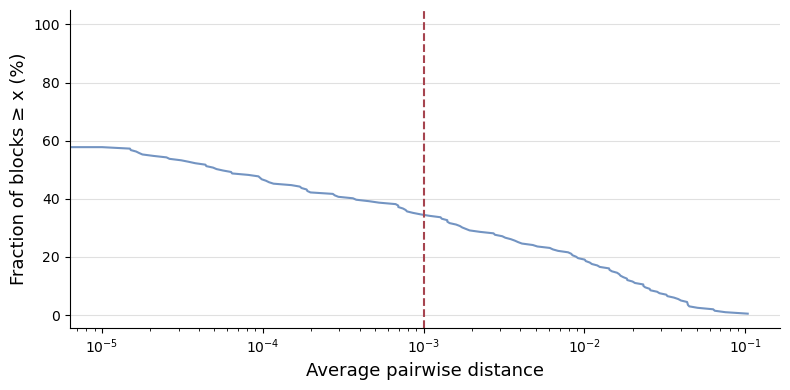

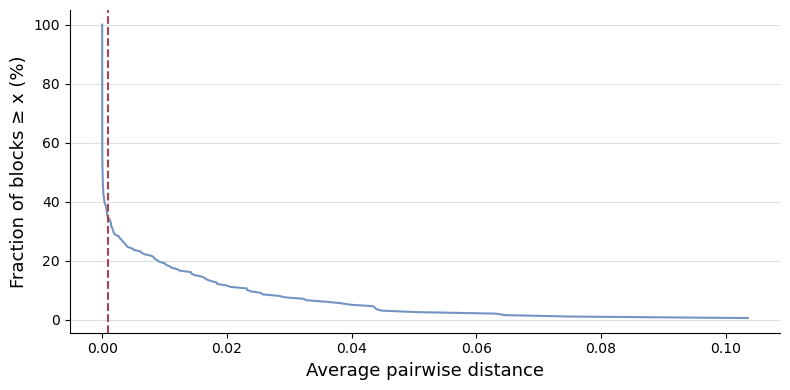

Percentage of ambiguous blocks out of all blocks: 3.440311208363725
21 junctions contain ambiguities. This are 4.054054054054054 %.
29.681978798586574 % of ambiguous blocks appear only once and are assumed to be gains.
46.28975265017668 % of ambiguous blocks have high sequence similarity and are assumed to be lost.
24.02826855123675 % of ambiguous blocks have low sequence similarity and are assumed to be independent gains.


In [21]:
# closer look at threshold 0.001

ambiguous_blocks_df = pd.read_csv("../results/consensus_analysis/ambiguous_blocks_0001.csv")
ambiguous_blocks_df = ambiguous_blocks_df[ambiguous_blocks_df.junction_name.isin(jdf_all.junction_name.to_list())]

# decision over block gain or loss is made based on average pairwise distances within all occurences of a block in a cluster
plot_ambiguous_block_distances(ambiguous_blocks_df, cumulative=True, log_x=True, vline=0.001)     
plot_ambiguous_block_distances(ambiguous_blocks_df, cumulative=True, log_x=False, vline=0.001)

n_ambiguous_blocks = ambiguous_blocks_df.n_ambiguous.sum()
n_single_isolate_blocks = ambiguous_blocks_df.n_single_isolate.sum()
n_decided_loss_blocks = ambiguous_blocks_df.n_decided_loss.sum()
n_decided_gain_blocks = ambiguous_blocks_df.n_decided_gain.sum()

print(f"Percentage of ambiguous blocks out of all blocks: {n_ambiguous_blocks / ambiguous_blocks_df.n_total_blocks.sum() * 100}")
print(f"{len(ambiguous_blocks_df[ambiguous_blocks_df['n_ambiguous'] > 0].junction_name.unique())} junctions contain ambiguities. This are {len(ambiguous_blocks_df[ambiguous_blocks_df['n_ambiguous'] > 0].junction_name.unique()) / len(jdf_all) * 100} %.")
print(f"{n_single_isolate_blocks / n_ambiguous_blocks * 100} % of ambiguous blocks appear only once and are assumed to be gains.")
print(f"{n_decided_loss_blocks / n_ambiguous_blocks * 100} % of ambiguous blocks have high sequence similarity and are assumed to be lost.")
print(f"{n_decided_gain_blocks / n_ambiguous_blocks * 100} % of ambiguous blocks have low sequence similarity and are assumed to be independent gains.")

#ambiguous_blocks_df[ambiguous_blocks_df['n_ambiguous'] > 0]